# Gothic Terrain DEM

Download a USGS 3DEP DEM for the Gothic area and plot terrain for `-107.2` to `-106.8` longitude and `38.75` to `39.15` latitude.

Using cached DEM: /glade/u/home/cdalden/goes_work/analysis/data/dem_gothic_box/usgs_3dep_dem_gothic_box.tif


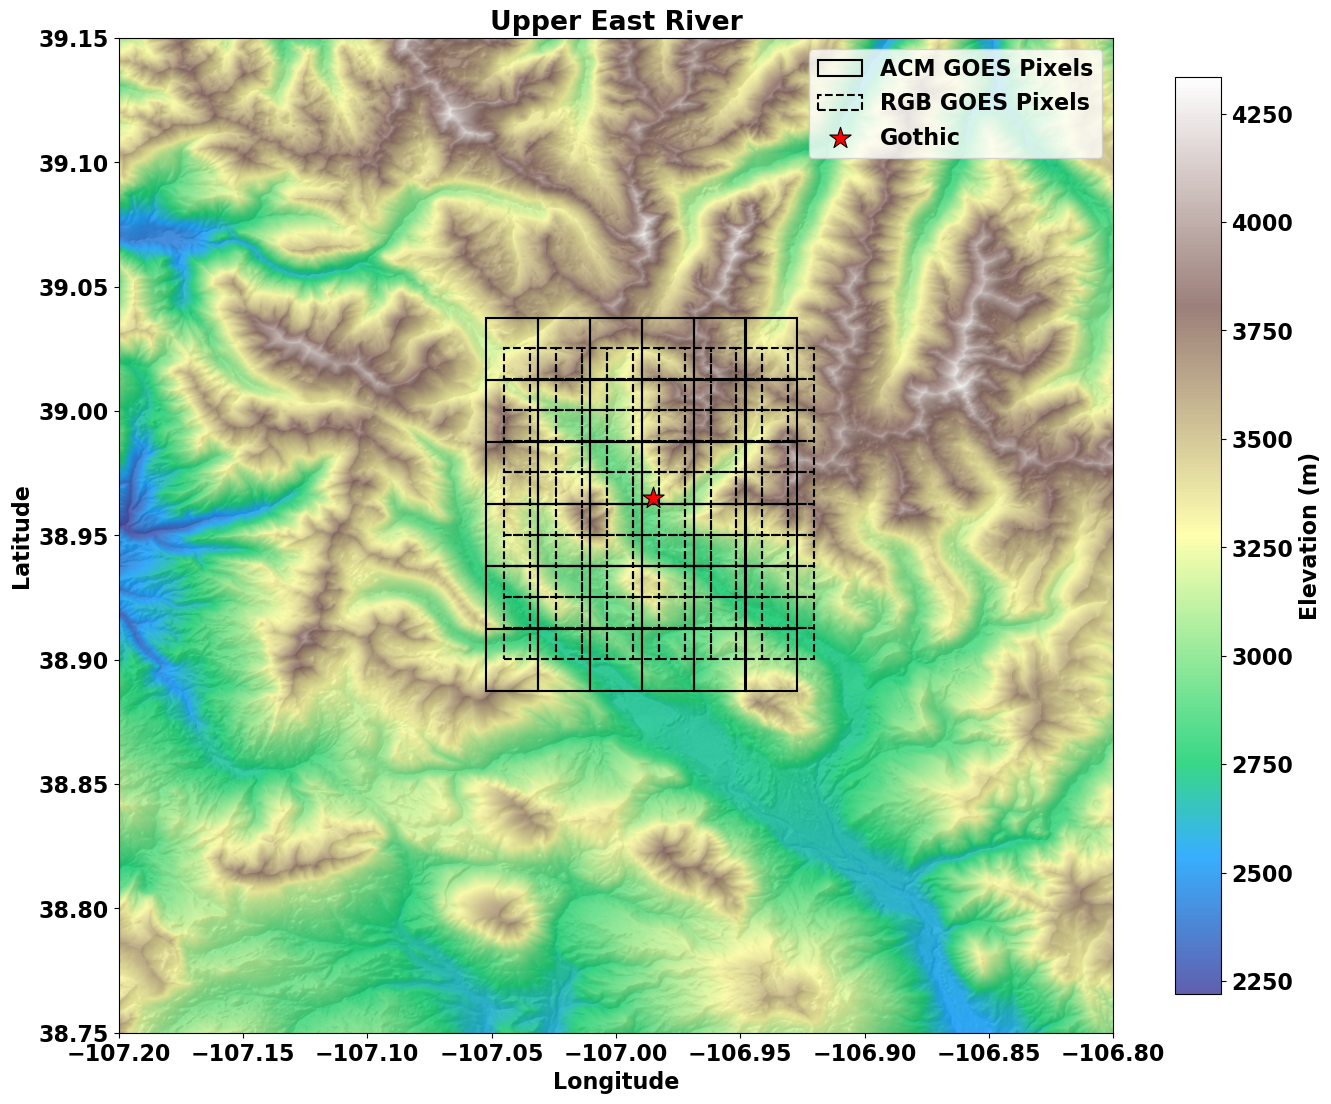

In [2]:
from io import BytesIO
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import requests
import xarray as xr
from matplotlib.patches import Rectangle
from PIL import Image

plt.rcParams["figure.figsize"] = (10, 8)
plt.rcParams["axes.grid"] = False
plt.rcParams["font.size"] = 16
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"

WEST, EAST = -107.2, -106.8
SOUTH, NORTH = 38.75, 39.15
BOUNDS = (WEST, SOUTH, EAST, NORTH)
BOX_WEST, BOX_EAST = -107.05, -106.92
BOX_SOUTH, BOX_NORTH = 38.90, 39.03

DEM_DIR = Path("/glade/u/home/cdalden/goes_work/analysis/data/dem_gothic_box")
DEM_DIR.mkdir(parents=True, exist_ok=True)
DEM_TIF = DEM_DIR / "usgs_3dep_dem_gothic_box.tif"
GOES_ACM_NC = Path("/glade/u/home/cdalden/scratch/colorado_acm/goes16/daily_nc_latlon/goes16_acm_colorado_20211002.nc")
GOES_RGB_NC = Path("/glade/u/home/cdalden/scratch/colorado_rgbmasks/cloud_mask_tempbin_10C/goes16_C02_C05_C13_rgb_colorado_20211002_cloud_binary_tempbin10c.nc")


def download_usgs_3dep_dem(bounds, out_path, pixels=1200):
    """Download a cropped USGS 3DEP DEM image for a lon/lat bounding box."""
    if out_path.exists():
        print(f"Using cached DEM: {out_path}")
        return out_path

    west, south, east, north = bounds
    url = "https://elevation.nationalmap.gov/arcgis/rest/services/3DEPElevation/ImageServer/exportImage"
    params = {
        "bbox": f"{west},{south},{east},{north}",
        "bboxSR": 4326,
        "imageSR": 4326,
        "size": f"{pixels},{pixels}",
        "format": "tiff",
        "pixelType": "F32",
        "noDataInterpretation": "esriNoDataMatchAny",
        "interpolation": "+RSP_BilinearInterpolation",
        "f": "image",
    }
    response = requests.get(url, params=params, timeout=120)
    response.raise_for_status()
    out_path.write_bytes(response.content)
    print(f"Downloaded DEM: {out_path}")
    return out_path


def hillshade(elevation, azimuth=315, altitude=45):
    """Simple hillshade for visual terrain relief."""
    filled = np.nan_to_num(elevation, nan=np.nanmedian(elevation))
    dy, dx = np.gradient(filled)
    slope = np.pi / 2 - np.arctan(np.hypot(dx, dy))
    aspect = np.arctan2(-dx, dy)
    azimuth_rad = np.deg2rad(azimuth)
    altitude_rad = np.deg2rad(altitude)
    shaded = (
        np.sin(altitude_rad) * np.sin(slope)
        + np.cos(altitude_rad) * np.cos(slope) * np.cos(azimuth_rad - aspect)
    )
    return np.clip((shaded + 1) / 2, 0, 1)


dem_path = download_usgs_3dep_dem(BOUNDS, DEM_TIF)

with Image.open(dem_path) as img:
    elevation = np.array(img, dtype=float)

elevation[elevation < -1000] = np.nan
extent = (WEST, EAST, SOUTH, NORTH)
shade = hillshade(elevation)

def get_goes_grid_in_box(nc_path):
    with xr.open_dataset(nc_path) as goes_ds:
        goes_lats = goes_ds["latitude"].values
        goes_lons = goes_ds["longitude"].values

    lat_step = abs(np.nanmedian(np.diff(goes_lats)))
    lon_step = abs(np.nanmedian(np.diff(goes_lons)))
    goes_lats_in_box = goes_lats[(goes_lats >= BOX_SOUTH) & (goes_lats <= BOX_NORTH)]
    goes_lons_in_box = goes_lons[(goes_lons >= BOX_WEST) & (goes_lons <= BOX_EAST)]
    return goes_lats_in_box, goes_lons_in_box, lat_step, lon_step

acm_lats, acm_lons, acm_lat_step, acm_lon_step = get_goes_grid_in_box(GOES_ACM_NC)
rgb_lats, rgb_lons, rgb_lat_step, rgb_lon_step = get_goes_grid_in_box(GOES_RGB_NC)

fig, ax = plt.subplots(figsize=(14, 12))
ax.imshow(shade, cmap="gray", extent=extent, origin="upper", alpha=0.55)
im = ax.imshow(elevation, cmap="terrain", extent=extent, origin="upper", alpha=0.78)
ax.set_xlim(WEST, EAST)
ax.set_ylim(SOUTH, NORTH)
def draw_goes_pixels(lats, lons, lat_step, lon_step, label, linestyle):
    handle = None
    for lat in lats:
        for lon in lons:
            pixel = Rectangle(
                (lon - lon_step / 2, lat - lat_step / 2),
                lon_step,
                lat_step,
                fill=False,
                edgecolor="black",
                linewidth=1.5,
                linestyle=linestyle,
                label=label if handle is None else None,
                zorder=5,
            )
            ax.add_patch(pixel)
            if handle is None:
                handle = pixel
    return handle

acm_pixel_handle = draw_goes_pixels(acm_lats, acm_lons, acm_lat_step, acm_lon_step, "ACM GOES Pixels", "solid")
rgb_pixel_handle = draw_goes_pixels(rgb_lats, rgb_lons, rgb_lat_step, rgb_lon_step, "RGB GOES Pixels", "--")

gothic_lon = (BOX_WEST + BOX_EAST) / 2
gothic_lat = (BOX_SOUTH + BOX_NORTH) / 2
gothic_marker = ax.scatter(
    gothic_lon,
    gothic_lat,
    marker="*",
    s=260,
    color="red",
    edgecolor="black",
    linewidth=0.8,
    label="Gothic",
    zorder=6,
)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Upper East River")
ax.legend(handles=[acm_pixel_handle, rgb_pixel_handle, gothic_marker], loc="upper right")
cbar = fig.colorbar(im, ax=ax, shrink=0.82)
cbar.set_label("Elevation (m)")
plt.tight_layout()
